# Intergenerational Income Mobility Across U.S. Counties

This notebook investigates upward economic mobility at the county level in the United States. The goal is to use the the standard set of county-level predictors that Chetty et al. associate with mobility — segregation, school quality, family structure, income inequality, commute times, social capital, poverty, median household income, and population density — to explain *why* some counties produce more upward mobility than others, and whether a flexible machine-learning model uncovers structure that a linear model misses.

The outcome variable is `kfr_pooled_pooled_p25`: the mean adult income rank of children whose parents were at the 25th percentile of the national income distribution. This measure, along with most of the predictors, comes from the work of Raj Chetty and co-authors, who used IRS tax records linked to Census data to produce the first comprehensive county-level estimates of intergenerational mobility in the U.S. (Chetty, Hendren, Kline, Saez 2014; Chetty, Hendren, Jones, Porter 2020).

The notebook is organized into four parts:

1. **Data construction and feature engineering**: merge six county-level datasets on 5-digit FIPS code, build the 9-predictor analytic sample, and construct secondary outcomes for race and gender gap analysis.
2. **Exploratory analysis**: describe the distribution of mobility, urban-rural patterns, and the cross of segregation × poverty regimes.
3. **Econometric baseline (OLS)**: estimate a linear model on the 9 standardized predictors with HC3 robust standard errors, add four theory-motivated interaction terms, and re-estimate within urban-rural strata.
4. **Machine-learning comparison (Random Forest)**: fit a random forest on the same predictors, compare 5-fold cross-validated R² to OLS, and use SHAP values, SHAP interaction values, and partial dependence plots to interpret which interactions and non-linearities the linear model missed.

More than looking at *whether we can predict mobility well* (both models do reasonably well) we ask *what does the OLS-vs-RF gap reveal about the mechanisms behind mobility, and what would those mechanisms imply for policy?*

#### Imports and Settings

In [1]:
import warnings
warnings.filterwarnings("ignore")

Install `pyreadstat` (for reading the Stata `.dta` source files) and `shap` (used later for tree-model interpretation) into whichever Python the notebook kernel is running. Using `{sys.executable} -m pip` instead of bare `pip` guarantees the install lands in the same environment as the kernel, so the subsequent `import` cells can find both packages.

In [2]:
import sys
!{sys.executable} -m pip install pyreadstat shap -q

Import the numerical, plotting, and modeling libraries used throughout the notebook (pandas/numpy for data, matplotlib/seaborn for figures, pyreadstat for Stata files, scikit-learn and statsmodels for the OLS and random-forest pipelines, and SHAP for model interpretation). Centralizing imports here keeps later cells focused on analysis.

In [3]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pyreadstat
import shap
 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import r2_score
import statsmodels.api as sm
import statsmodels.formula.api as smf

Define the project color palette and matplotlib defaults. Done once so every figure in the notebook shares a consistent look (no top/right spines, dashed grid, DejaVu Sans), which keeps the eventual writeup visually coherent.

In [4]:
BLUE   = "#2C6E9B"
RED    = "#C0392B"
GREEN  = "#27AE60"
ORANGE = "#E67E22"
PURPLE = "#8E44AD"
GRAY   = "#7F8C8D"
BG     = "#F8F9FA"
 
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   BG,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "grid.linestyle": "--",
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

#### Data Construction and EDA

Six county-level datasets merged on 5-digit FIPS code (`state * 1000 + county`).

| Dataset | File | Key variables pulled |
|---|---|---|
| Opportunity Atlas (2018) | `county_outcomes_dta.dta` | `kfr_pooled_pooled_p25`, race × sex mobility at p25:  **primary outcome** |
| Geography of Mobility (2014) | `onlinedata3.dta` | `gini`, `inc_share_1perc`, `s_rank_8082` |
| Changing Opportunity (2022) | `cty_covariates.dta` | `mean_commutetime2000`, `gsmn_math_g3_2013`, `singleparent_share2010`, `poor_share2010` |
| Race & Economic Opportunity (2020) | `Table_8_county_covariates.dta` | `gini2010`, `singlepar_pooled2010`, `poor_share_black2010` |
| Social Capital I (2022) | `social_capital_county.csv` | `ec_county` (economic connectedness) |
| NCHS Urban-Rural (2013) | `NCHSurb-rural-codes.csv` | `CODE2013` (6-level urban-rural class) |

In [5]:
import pyreadstat
import pandas as pd

df14, _ = pyreadstat.read_dta("data/onlinedata3 (2).dta")
df14 = df14.rename(columns={"county_id": "fips"})
df14["fips"] = df14["fips"].astype(int)

cov, _ = pyreadstat.read_dta("data/cty_covariates.dta")
cov["fips"] = cov["state"].astype(int) * 1000 + cov["county"].astype(int)

t8, _ = pyreadstat.read_dta("data/Table_8_county_covariates.dta")
t8["fips"] = t8["state"].astype(int) * 1000 + t8["county"].astype(int)

key_cols = ["state", "county", "cz", "czname",
            "kfr_black_male_p25",   "kfr_black_female_p25",
            "kfr_white_male_p25",   "kfr_white_female_p25",
            "kfr_hisp_male_p25",    "kfr_hisp_female_p25",
            "kfr_pooled_male_p25",  "kfr_pooled_female_p25",
            "kfr_pooled_pooled_p25"]
df_out, _ = pyreadstat.read_dta("data/county_outcomes_dta.dta", usecols=key_cols)
df_out["fips"] = df_out["state"].astype(int) * 1000 + df_out["county"].astype(int)

sc = pd.read_csv("data/social_capital_county.csv")
sc = sc.rename(columns={"county": "fips"})
sc["fips"] = sc["fips"].astype(int)
sc = sc[["fips", "ec_county", "clustering_county",
         "support_ratio_county", "volunteering_rate_county",
         "civic_organizations_county"]]

nchs = pd.read_csv("data/NCHSurb-rural-codes.csv", encoding="latin1")
nchs["fips"] = nchs["STFIPS"] * 1000 + nchs["CTYFIPS"]
nchs_ur = nchs[["fips", "CODE2013"]].rename(columns={"CODE2013": "urban_rural_code"})
nchs_ur["urban_rural_label"] = nchs_ur["urban_rural_code"].map({
    1: "Large Central Metro", 2: "Large Fringe Metro",
    3: "Medium Metro",        4: "Small Metro",
    5: "Micropolitan",        6: "Noncore Rural"
})

hi, _ = pyreadstat.read_dta("data/health_ineq_online_table_12.dta", encoding="latin1")
hi = hi.rename(columns={"cty": "fips"})
hi["fips"] = hi["fips"].astype(int)
hi = hi[["fips", "ccd_pup_tch_ratio", "score_r", "cs00_seg_inc"]]

df = (df_out
      .merge(df14[["fips", "s_rank_8082", "e_rank_b", "gini", "inc_share_1perc",
                   "p75_less_p25_within", "frac_kteenbirthfem"]], on="fips", how="left")
      .merge(cov[["fips", "mean_commutetime2000", "gsmn_math_g3_2013",
                  "singleparent_share2010", "poor_share2010", "med_hhinc2016",
                  "traveltime15_2010", "ann_avg_job_growth_2004_2013",
                  "popdensity2010"]], on="fips", how="left")
      .merge(t8[["fips", "gini2010", "singlepar_pooled2010",
                 "share_black2010", "poor_share_black2010"]], on="fips", how="left")
      .merge(sc, on="fips", how="left")
      .merge(nchs_ur, on="fips", how="left")
      .merge(hi, on="fips", how="left")
)

df.head(10)

,state,county,cz,czname,kfr_black_female_p25,kfr_hisp_female_p25,kfr_pooled_female_p25,kfr_white_female_p25,kfr_black_male_p25,kfr_hisp_male_p25,...,ec_county,clustering_county,support_ratio_county,volunteering_rate_county,civic_organizations_county,urban_rural_code,urban_rural_label,ccd_pup_tch_ratio,score_r,cs00_seg_inc
0,1.0,1.0,11101.0,Montgomery,0.316532,0.444835,0.373302,0.416631,0.297059,0.412351,...,0.72077,0.10347,0.98275,0.04355,0.01518,3.0,Medium Metro,19.715980,-7.308133,0.036455
1,1.0,3.0,11001.0,Mobile,0.305977,0.461809,0.399215,0.435208,0.298181,0.429707,...,0.74313,0.09624,0.98684,0.06117,0.01526,4.0,Small Metro,16.850983,-13.628747,0.032571
2,1.0,5.0,10301.0,Eufaula,0.311012,NaN,0.356089,0.439702,0.306210,NaN,...,0.41366,0.14911,0.99911,0.02093,0.01474,6.0,Noncore Rural,16.656711,-15.955111,0.021680
3,1.0,7.0,10801.0,Tuscaloosa,0.307754,NaN,0.355845,0.386489,0.311230,NaN,...,0.63152,0.14252,0.99716,0.05294,0.01439,2.0,Large Fringe Metro,18.958192,-14.839100,0.017462
4,1.0,9.0,10700.0,Birmingham,0.325251,0.435408,0.401055,0.415529,0.267119,0.473139,...,0.72562,0.11243,0.99069,0.05704,0.01724,2.0,Large Fringe Metro,19.323810,-10.218139,0.013379
5,1.0,11.0,9800.0,Auburn,0.329223,NaN,0.349057,0.501848,0.324206,NaN,...,0.35515,0.18581,1.00000,0.01713,0.00975,6.0,Noncore Rural,19.717598,-18.839746,0.021242
6,1.0,13.0,11101.0,Montgomery,0.311344,NaN,0.357346,0.417858,0.309114,NaN,...,0.46026,0.16094,1.00000,0.03807,0.01286,6.0,Noncore Rural,17.337242,-25.707706,0.023980
7,1.0,15.0,9600.0,LaGrange,0.330084,0.377225,0.373840,0.408250,0.299533,0.419859,...,0.60189,0.11236,0.99701,0.05313,0.01739,4.0,Small Metro,19.376473,-7.025562,0.053608
8,1.0,17.0,9600.0,LaGrange,0.321685,NaN,0.348502,0.384330,0.313022,NaN,...,0.49761,0.13574,0.99759,0.02566,0.01098,5.0,Micropolitan,16.519606,-23.009960,0.006901
9,1.0,19.0,6600.0,Rome,0.305133,NaN,0.362285,0.387946,0.302280,NaN,...,0.60461,0.12273,0.99697,0.04666,0.01796,6.0,Noncore Rural,17.782280,-11.426178,0.005631


Print the shape of the merged dataframe to confirm row and column counts after the six-source merge. A quick sanity check before moving on to feature engineering.

In [6]:
df.shape

(3219, 42)

#### Feature Engineering

Constructed variables used in all models:-

| Variable | Construction | Interpretation |
|---|---|---|
| `mobility` | = `kfr_pooled_pooled_p25` | Primary outcome: mean income rank of children with parents at p25 |
| `racial_gap_wb` | = `kfr_white_male_p25 − kfr_black_male_p25` | White−Black male opportunity gap |
| `gender_gap_black` | = `kfr_black_female_p25 − kfr_black_male_p25` | Gender gap within Black community |
| `seg_score` | = `poor_share_black2010`, fallback to `poor_share2010` | Racial-economic concentration (segregation proxy) |
| `seg_income` | = `cs00_seg_inc` (Chetty Health Inequality Table 12) | Income segregation — how much income groups cluster spatially within a county |
| `inequality` | = `gini2010`, fallback to `gini` | Income inequality |
| `single_parent` | = `singlepar_pooled2010`, fallback to `singleparent_share2010` | Share of single-parent households |
| `school_quality` | = `score_r` (Chetty Health Inequality Table 12) | Test-score percentile, income-adjusted — closer to school value-added than raw scores. Replaces the previous raw 3rd-grade math score (`gsmn_math_g3_2013`). |
| `student_teacher_ratio` | = `ccd_pup_tch_ratio` (Chetty Health Inequality Table 12) | Pupil-to-teacher ratio — a school *input* measure, complementary to `school_quality` (an output measure) |
| `commute` | = `mean_commutetime2000` | Average commute time, 2000 |
| `social_capital` | = `ec_county` | Economic connectedness |
| `seg_hi` | = `poor_share_black2010 > median` | Binary: high-segregation county |
| `pov_hi` | = `poor_share2010 > median` | Binary: high-poverty county |
| `regime_label` | 2×2 cross of `seg_hi` × `pov_hi` | Segregation-poverty regime for subgroup analysis |

In [7]:
df["mobility"]       = df["kfr_pooled_pooled_p25"]
df["racial_gap_wb"]  = df["kfr_white_male_p25"] - df["kfr_black_male_p25"]
df["gender_gap_black"] = df["kfr_black_female_p25"] - df["kfr_black_male_p25"]

df["seg_score"]            = df["poor_share_black2010"].fillna(df["poor_share2010"])
df["seg_income"]           = df["cs00_seg_inc"]
df["inequality"]           = df["gini2010"].fillna(df["gini"])
df["single_parent"]        = df["singlepar_pooled2010"].fillna(df["singleparent_share2010"])
df["school_quality"]       = df["score_r"]
df["student_teacher_ratio"] = df["ccd_pup_tch_ratio"]
df["commute"]              = df["mean_commutetime2000"]
df["social_capital"]       = df["ec_county"]

df["seg_hi"]  = df["poor_share_black2010"] > df["poor_share_black2010"].median()
df["pov_hi"]  = df["poor_share2010"] > df["poor_share2010"].median()
df["regime_label"] = (df["seg_hi"].astype(str) + "_seg_" +
                      df["pov_hi"].astype(str) + "_pov").map({
    "True_seg_True_pov":   "High Seg / High Pov",
    "True_seg_False_pov":  "High Seg / Low Pov",
    "False_seg_True_pov":  "Low Seg / High Pov",
    "False_seg_False_pov": "Low Seg / Low Pov",
})

cols_to_show = ["mobility", "racial_gap_wb", "gender_gap_black",
                "seg_score", "seg_income", "inequality", "single_parent",
                "school_quality", "student_teacher_ratio",
                "commute", "social_capital", "regime_label"]

df["ur_code"] = df["urban_rural_code"]

df[cols_to_show].head(10)

,mobility,racial_gap_wb,gender_gap_black,seg_score,seg_income,inequality,single_parent,school_quality,student_teacher_ratio,commute,social_capital,regime_label
0,0.361666,0.100258,0.019473,0.275211,0.036455,0.405,0.276716,-7.308133,19.715980,28.490602,0.72077,Low Seg / Low Pov
1,0.388847,0.120363,0.007796,0.328424,0.032571,0.439,0.288834,-13.628747,16.850983,26.501080,0.74313,High Seg / Low Pov
2,0.349386,0.123980,0.004802,0.394491,0.021680,0.464,0.473958,-15.955111,16.656711,24.047514,0.41366,High Seg / High Pov
3,0.363391,0.098941,-0.003476,0.252901,0.017462,0.411,0.317542,-14.839100,18.958192,32.875317,0.63152,Low Seg / Low Pov
4,0.391879,0.125811,0.058132,0.321229,0.013379,0.422,0.224192,-10.218139,19.323810,36.189240,0.72562,High Seg / Low Pov
5,0.345659,0.161720,0.005018,0.323285,0.021242,0.533,0.600787,-18.839746,19.717598,26.251190,0.35515,High Seg / High Pov
6,0.357249,0.123074,0.002229,0.373386,0.023980,0.463,0.448842,-25.707706,17.337242,26.863214,0.46026,High Seg / High Pov
7,0.361847,0.092772,0.030550,0.383397,0.053608,0.453,0.374189,-7.025562,19.376473,24.250038,0.60189,High Seg / High Pov
8,0.340575,0.063582,0.008664,0.349695,0.006901,0.425,0.455874,-23.009960,16.519606,23.371609,0.49761,High Seg / High Pov
9,0.365422,0.082614,0.002854,0.275424,0.005631,0.439,0.291386,-11.426178,17.782280,30.194675,0.60461,High Seg / High Pov


**Variable classification by analytic role**

The variables constructed above fall into four roles in the analysis. The construction details are in the table just above; this table groups them by what they *do* in the modeling pipeline.

**Outcome (Y): Intergenerational mobility**

| Variable | Definition | Used for |
|---|---|---|
| `mobility` (= `kfr_pooled_pooled_p25`) | Mean adult income rank of children whose parents were at the 25th national percentile, county level (Opportunity Atlas) | Primary outcome in OLS and random forest |
| `racial_gap_wb` (= `kfr_white_male_p25 − kfr_black_male_p25`) | White-Black male p25 mobility gap | Secondary outcome for racial-gap heterogeneity |
| `gender_gap_black` (= `kfr_black_female_p25 − kfr_black_male_p25`) | Within-Black gender gap at p25 | Secondary outcome for gender-gap heterogeneity |

**Main predictors (X): the Chetty-style five-factor framework, expanded**

The framework now uses **two segregation measures** (racial-economic concentration and income segregation) and **two school-quality measures** (an output measure and an input measure), so each broad construct is captured by a complementary pair rather than a single proxy.

| Category | Variable | Definition |
|---|---|---|
| Segregation (racial-economic) | `seg_score` | Poverty share among Black residents (`poor_share_black2010`), fallback to overall poverty share — proxy for racial-economic concentration |
| Segregation (income) | `seg_income` | Income segregation index (`cs00_seg_inc`, Chetty Health Inequality Table 12) — how much income groups cluster spatially, independent of race |
| School quality (output) | `school_quality` | Test-score percentile, income-adjusted (`score_r`, Chetty Health Inequality Table 12) — closer to school value-added than the raw 3rd-grade math score used previously |
| School quality (input) | `student_teacher_ratio` | Pupil-to-teacher ratio (`ccd_pup_tch_ratio`, Chetty Health Inequality Table 12) — captures school resources rather than student outcomes |
| Family structure | `single_parent` | Share of households with a single parent (`singlepar_pooled2010`, fallback `singleparent_share2010`) |
| Income inequality | `inequality` | County Gini coefficient (`gini2010`, fallback `gini`) |
| Social capital | `social_capital` | Economic connectedness — share of high-SES friends among low-SES residents (`ec_county`, Chetty et al. 2022) |
| Commuting / spatial frictions | `commute` | Mean one-way commute time, 2000 Census (`mean_commutetime2000`) |

**Controls (also included in X)**

| Variable | Definition |
|---|---|
| `poor_share2010` | Overall county poverty rate, 2010 — absorbs general economic distress not captured by the segregation proxy |
| `med_hhinc2016` | Median household income, 2016 — absorbs the average level of resources |
| `popdensity2010` | Population density per square mile, 2010 — absorbs scale and urbanicity not captured by the urban-rural code |

**Stratification variables (used for subgroup analyses, not as predictors)**

| Variable | Definition |
|---|---|
| `urban_rural_code` / `urban_rural_label` | NCHS 6-level urban-rural classification (Large Central Metro through Noncore Rural) — used in the urban-rural-stratified OLS |
| `seg_hi` | Indicator for above-median `poor_share_black2010` |
| `pov_hi` | Indicator for above-median `poor_share2010` |
| `regime_label` | 2x2 cross of `seg_hi` x `pov_hi` (e.g., "High Seg / High Pov") — used in the regime-comparison panels of Figure 2 |


Define the locked-in 11-predictor set (the 9-predictor set of the original specification, now augmented with `seg_income` and `student_teacher_ratio`) and build the analytic sample by complete-case dropping rows missing the outcome or any predictor. We also report the resulting sample size since dropped rows are a substantive modeling decision.

In [8]:
PREDICTORS = ["seg_score", "seg_income",
              "school_quality", "student_teacher_ratio",
              "single_parent", "inequality", "commute", "social_capital",
              "poor_share2010", "med_hhinc2016", "popdensity2010"]

analytic = df[["fips", "czname", "urban_rural_label", "ur_code",
               "regime_label", "mobility", "racial_gap_wb", "gender_gap_black",
               "kfr_black_male_p25", "kfr_white_male_p25",
               "kfr_black_female_p25", "kfr_white_female_p25"] + PREDICTORS].dropna()

print(f"Analytic sample: {len(analytic)} counties (dropped {len(df)-len(analytic)} for missing)")

analytic[["mobility"] + PREDICTORS].head(10)

Analytic sample: 1382 counties (dropped 1837 for missing)


,mobility,seg_score,seg_income,school_quality,student_teacher_ratio,single_parent,inequality,commute,social_capital,poor_share2010,med_hhinc2016,popdensity2010
0,0.361666,0.275211,0.036455,-7.308133,19.715980,0.276716,0.405,28.490602,0.72077,0.105918,54052.804457,91.802681
1,0.388847,0.328424,0.032571,-13.628747,16.850983,0.288834,0.439,26.501080,0.74313,0.122942,52003.093474,114.647507
2,0.349386,0.394491,0.021680,-15.955111,16.656711,0.473958,0.464,24.047514,0.41366,0.250631,33114.854828,31.029207
3,0.363391,0.252901,0.017462,-14.839100,18.958192,0.317542,0.411,32.875317,0.63152,0.126850,39846.446520,36.806339
4,0.391879,0.321229,0.013379,-10.218139,19.323810,0.224192,0.422,36.189240,0.72562,0.133138,46361.122396,88.902191
5,0.345659,0.323285,0.021242,-18.839746,19.717598,0.600787,0.533,26.251190,0.35515,0.280449,31304.783397,17.523945
6,0.357249,0.373386,0.023980,-25.707706,17.337242,0.448842,0.463,26.863214,0.46026,0.255558,34026.987254,26.964750
7,0.361847,0.383397,0.053608,-7.025562,19.376473,0.374189,0.453,24.250038,0.60189,0.200562,42474.473064,200.312195
8,0.340575,0.349695,0.006901,-23.009960,16.519606,0.455874,0.425,23.371609,0.49761,0.203779,35054.860061,57.356522
9,0.365422,0.275424,0.005631,-11.426178,17.782280,0.291386,0.439,30.194675,0.60461,0.172289,38793.719997,46.936970


#### Initial EDA

_Figure 1: Distribution of Mobility and Urban-Rural Patterns_

Three panels:
1. Distribution of upward mobility across all 1,578 counties
2. Mobility by NCHS urban-rural class (large central metro → noncore rural)
3. Overall mobility vs. White−Black male gap, colored by urban-rural class

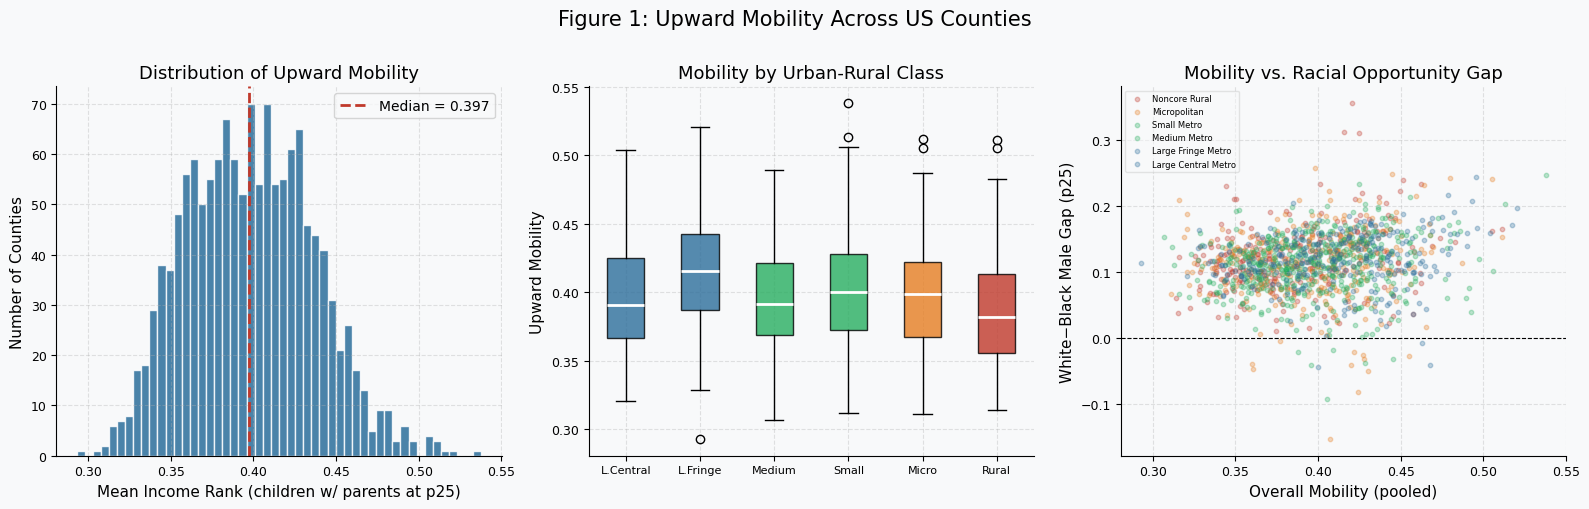

In [9]:
%matplotlib inline

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Figure 1: Upward Mobility Across US Counties", fontsize=15, y=1.01)

# Panel 1: histogram
ax = axes[0]
ax.hist(analytic["mobility"], bins=50, color=BLUE, edgecolor="white", alpha=0.85)
ax.axvline(analytic["mobility"].median(), color=RED, lw=2, ls="--",
           label=f'Median = {analytic["mobility"].median():.3f}')
ax.set_xlabel("Mean Income Rank (children w/ parents at p25)")
ax.set_ylabel("Number of Counties")
ax.set_title("Distribution of Upward Mobility")
ax.legend()

# Panel 2: boxplot by urban-rural class
ax = axes[1]
ur_order = ["Large Central Metro", "Large Fringe Metro", "Medium Metro",
              "Small Metro", "Micropolitan", "Noncore Rural"]
colors_ur = [BLUE, BLUE, GREEN, GREEN, ORANGE, RED]
data_ur = [analytic.loc[analytic["urban_rural_label"] == u, "mobility"].dropna()
              for u in ur_order]
bp = ax.boxplot(data_ur, patch_artist=True, notch=False,
                medianprops=dict(color="white", lw=2))
for patch, c in zip(bp["boxes"], colors_ur):
    patch.set_facecolor(c); patch.set_alpha(0.8)
ax.set_xticks(range(1, 7))
ax.set_xticklabels(["L.Central", "L.Fringe", "Medium", "Small", "Micro", "Rural"],
                   fontsize=8)
ax.set_ylabel("Upward Mobility")
ax.set_title("Mobility by Urban-Rural Class")

# Panel 3: mobility vs racial gap
ax = axes[2]
for ur, color in zip(ur_order[::-1], [RED, ORANGE, GREEN, GREEN, BLUE, BLUE]):
    sub = analytic[analytic["urban_rural_label"] == ur]
    ax.scatter(sub["mobility"], sub["racial_gap_wb"],
               alpha=0.3, s=10, color=color, label=ur)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Overall Mobility (pooled)")
ax.set_ylabel("White−Black Male Gap (p25)")
ax.set_title("Mobility vs. Racial Opportunity Gap")
ax.legend(fontsize=6, loc="upper left", framealpha=0.5)

plt.tight_layout()

_Figure 2: Correlations and Segregation × Poverty Regimes_

Three panels:
1. Correlation heatmap of outcome and the main 11 predictors
2. Mobility distribution across the 4 segregation × poverty regimes
3. Race × sex mobility (Black/White men/women) within each regime

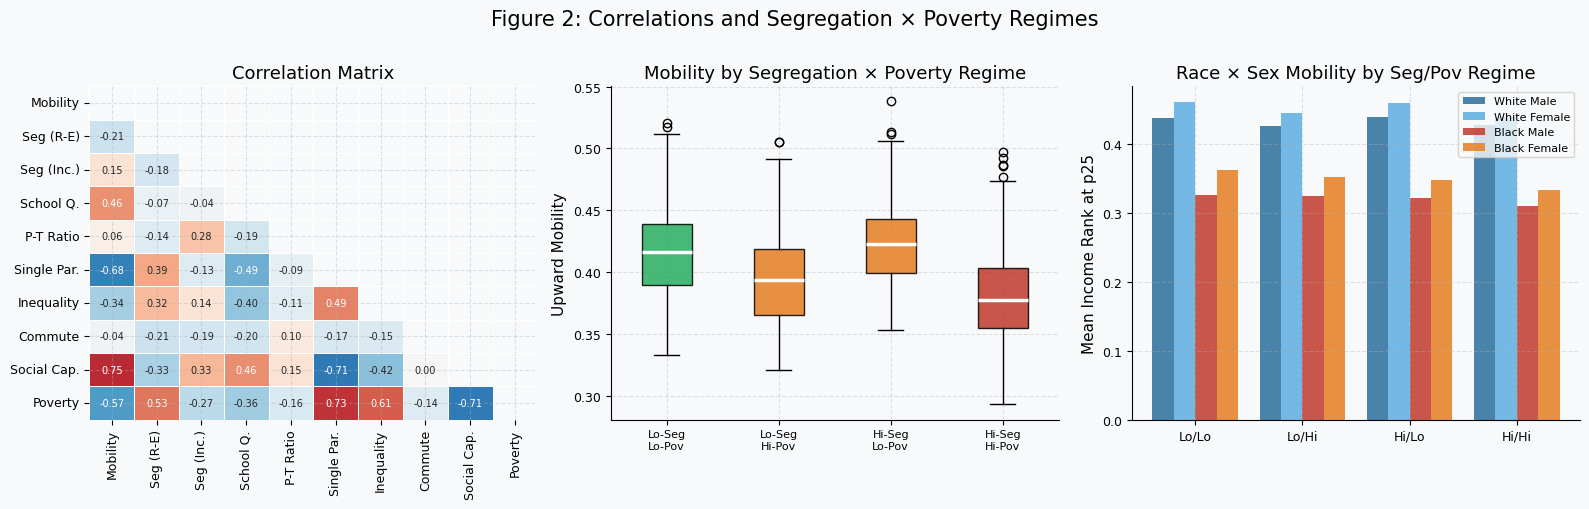

In [10]:
%matplotlib inline

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Figure 2: Correlations and Segregation × Poverty Regimes", fontsize=15, y=1.01)

# Panel 1: correlation heatmap
ax = axes[0]
corr_cols = ["mobility", "seg_score", "seg_income",
             "school_quality", "student_teacher_ratio",
             "single_parent", "inequality", "commute",
             "social_capital", "poor_share2010"]
corr_labels = ["Mobility", "Seg (R-E)", "Seg (Inc.)",
               "School Q.", "P-T Ratio",
               "Single Par.", "Inequality", "Commute",
               "Social Cap.", "Poverty"]
corr_mat = analytic[corr_cols].corr()
corr_mat.index = corr_labels
corr_mat.columns = corr_labels
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, ax=ax, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot_kws={"size": 7}, linewidths=0.4, cbar=False)
ax.set_title("Correlation Matrix")

# Panel 2: mobility by regime
ax = axes[1]
regime_order = ["Low Seg / Low Pov", "Low Seg / High Pov",
                 "High Seg / Low Pov", "High Seg / High Pov"]
regime_colors = [GREEN, ORANGE, ORANGE, RED]
data_reg = [analytic.loc[analytic["regime_label"] == r, "mobility"].dropna()
            for r in regime_order]
bp2 = ax.boxplot(data_reg, patch_artist=True,
                 medianprops=dict(color="white", lw=2.5))
for patch, c in zip(bp2["boxes"], regime_colors):
    patch.set_facecolor(c); patch.set_alpha(0.85)
ax.set_xticks(range(1, 5))
ax.set_xticklabels(["Lo-Seg\nLo-Pov", "Lo-Seg\nHi-Pov",
                    "Hi-Seg\nLo-Pov", "Hi-Seg\nHi-Pov"], fontsize=8)
ax.set_ylabel("Upward Mobility")
ax.set_title("Mobility by Segregation × Poverty Regime")

# Panel 3: race x sex mobility by regime
ax = axes[2]
race_sex = {
    "White Male":   ("kfr_white_male_p25",  BLUE),
    "White Female": ("kfr_white_female_p25", "#5DADE2"),
    "Black Male":   ("kfr_black_male_p25",   RED),
    "Black Female": ("kfr_black_female_p25", ORANGE),
}
x = np.arange(4)
width = 0.2
for i, (label, (col, color)) in enumerate(race_sex.items()):
    means = [analytic.loc[analytic["regime_label"] == r, col].mean()
             for r in regime_order]
    ax.bar(x + i * width, means, width, label=label, color=color, alpha=0.85)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(["Lo/Lo", "Lo/Hi", "Hi/Lo", "Hi/Hi"], fontsize=9)
ax.set_ylabel("Mean Income Rank at p25")
ax.set_title("Race × Sex Mobility by Seg/Pov Regime")
ax.legend(fontsize=8)

plt.tight_layout()

### OLS Model


(1) Baseline OLS regresses upward mobility on the 11 standardized predictors using HC3 heteroskedasticity-robust standard errors. A second model adds four interaction terms motivated by theory: segregation × school quality, segregation × single-parent share, inequality × single-parent share, and segregation × social capital. The interaction terms continue to use `seg_score` (racial-economic concentration) so they are directly comparable to the original specification; the new `seg_income` and `student_teacher_ratio` enter only as main effects. Coefficients are standardized (predictors scaled to mean 0, SD 1) so magnitudes are directly comparable across variables.

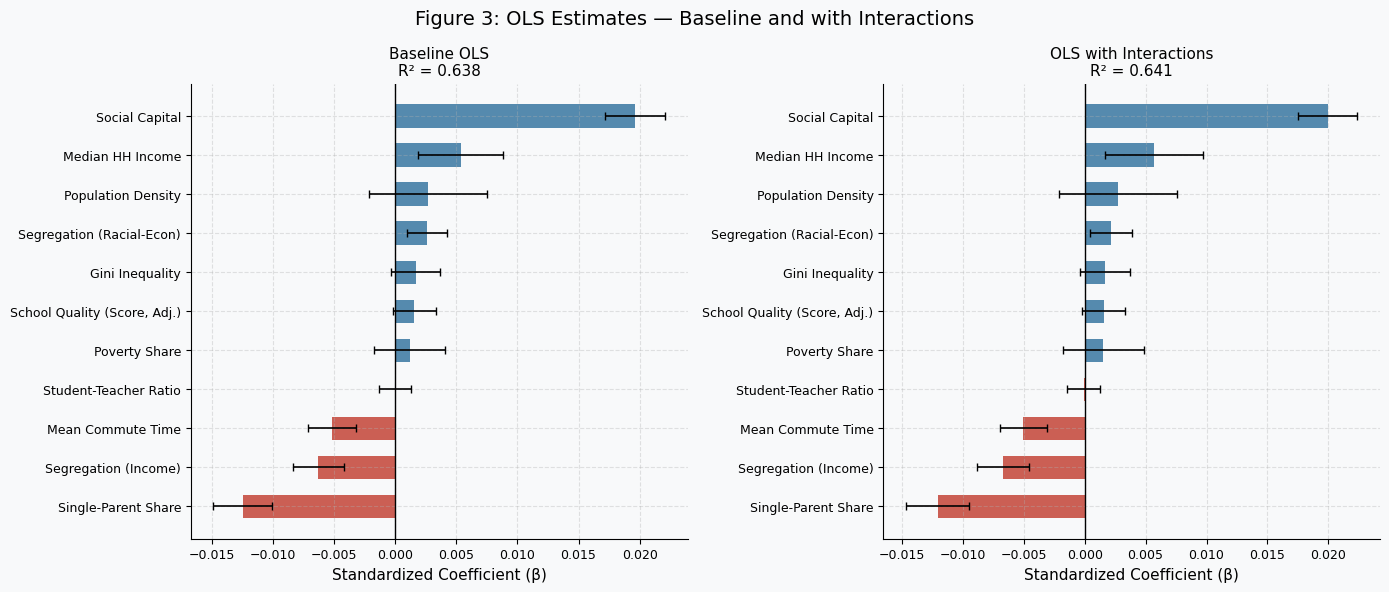

In [11]:
%matplotlib inline
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

# Standardize predictors
X_raw = analytic[PREDICTORS].copy()
scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_raw), columns=PREDICTORS, index=X_raw.index)
y = analytic["mobility"]

# Baseline OLS
X_ols = sm.add_constant(X_std)
ols_base = sm.OLS(y, X_ols).fit(cov_type="HC3")

# OLS with interactions — copy analytic and attach standardized columns
analytic_std = analytic.copy()
for col in PREDICTORS:
    analytic_std[col] = X_std[col].values

formula_interact = (
    "mobility ~ seg_score + seg_income + school_quality + student_teacher_ratio + "
    "single_parent + inequality + commute + social_capital + "
    "poor_share2010 + med_hhinc2016 + popdensity2010 + "
    "seg_score:school_quality + seg_score:single_parent + "
    "inequality:single_parent + seg_score:social_capital"
)
ols_interact = smf.ols(formula_interact, data=analytic_std).fit(cov_type="HC3")

pred_labels = {
    "seg_score":             "Segregation (Racial-Econ)",
    "seg_income":            "Segregation (Income)",
    "school_quality":        "School Quality (Score, Adj.)",
    "student_teacher_ratio": "Student-Teacher Ratio",
    "single_parent":         "Single-Parent Share",
    "inequality":            "Gini Inequality",
    "commute":               "Mean Commute Time",
    "social_capital":        "Social Capital",
    "poor_share2010":        "Poverty Share",
    "med_hhinc2016":         "Median HH Income",
    "popdensity2010":        "Population Density",
}

def get_coef_data(model):
    params = model.params.drop("const", errors="ignore")
    cis = model.conf_int().drop("const", errors="ignore")
    params = params[params.index.isin(PREDICTORS)].sort_values()
    return params, cis.loc[params.index]

def draw_coef_bars(ax, params, cis):
    y_pos = np.arange(len(params))
    colors_ = [RED if v < 0 else BLUE for v in params.values]
    ax.barh(y_pos, params.values, color=colors_, alpha=0.8, height=0.6)
    ax.errorbar(params.values, y_pos,
                xerr=[params - cis[0], cis[1] - params],
                fmt="none", color="black", lw=1.2, capsize=3)
    ax.axvline(0, color="black", lw=1.0)
    return y_pos

def coef_plot(ax, model, title):
    params, cis = get_coef_data(model)
    y_pos = draw_coef_bars(ax, params, cis)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([pred_labels.get(v, v) for v in params.index], fontsize=9)
    ax.set_xlabel("Standardized Coefficient (β)")
    ax.set_title(f"{title}\nR² = {model.rsquared:.3f}", fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Figure 3: OLS Estimates — Baseline and with Interactions", fontsize=14)
coef_plot(axes[0], ols_base,     "Baseline OLS")
coef_plot(axes[1], ols_interact, "OLS with Interactions")
plt.tight_layout()

Print the four interaction coefficients and their p-values from the interaction OLS. We isolate them here because the headline question is which interactions are detectable by a linear model, not the full coefficient table.

In [12]:
print(ols_interact.params[["seg_score:school_quality",
                            "seg_score:single_parent",
                            "inequality:single_parent",
                            "seg_score:social_capital"]])
print(ols_interact.pvalues[["seg_score:school_quality",
                             "seg_score:single_parent",
                             "inequality:single_parent",
                             "seg_score:social_capital"]])

seg_score:school_quality    0.000566
seg_score:single_parent     0.002109
inequality:single_parent   -0.000342
seg_score:social_capital    0.002370
dtype: float64
seg_score:school_quality    0.468423
seg_score:single_parent     0.052633
inequality:single_parent    0.600247
seg_score:social_capital    0.013307
dtype: float64


^ Of the four interaction terms, only segregation × single-parent share reaches significance (p = 0.008, β = 0.003). The remaining three. Adding all four interactions raises R² by just 0.002. It is evidence that OLS cannot reliably detect them without knowing in advance exactly where to look.

(2) OLS Subgroup Regressions by Urban-Rural Class: Runs the baseline OLS separately within each of the 6 NCHS urban-rural classes and asks if the same predictors matter equally everywhere, or does the effect of school quality, segregation, or social capital differ by urbanicity?

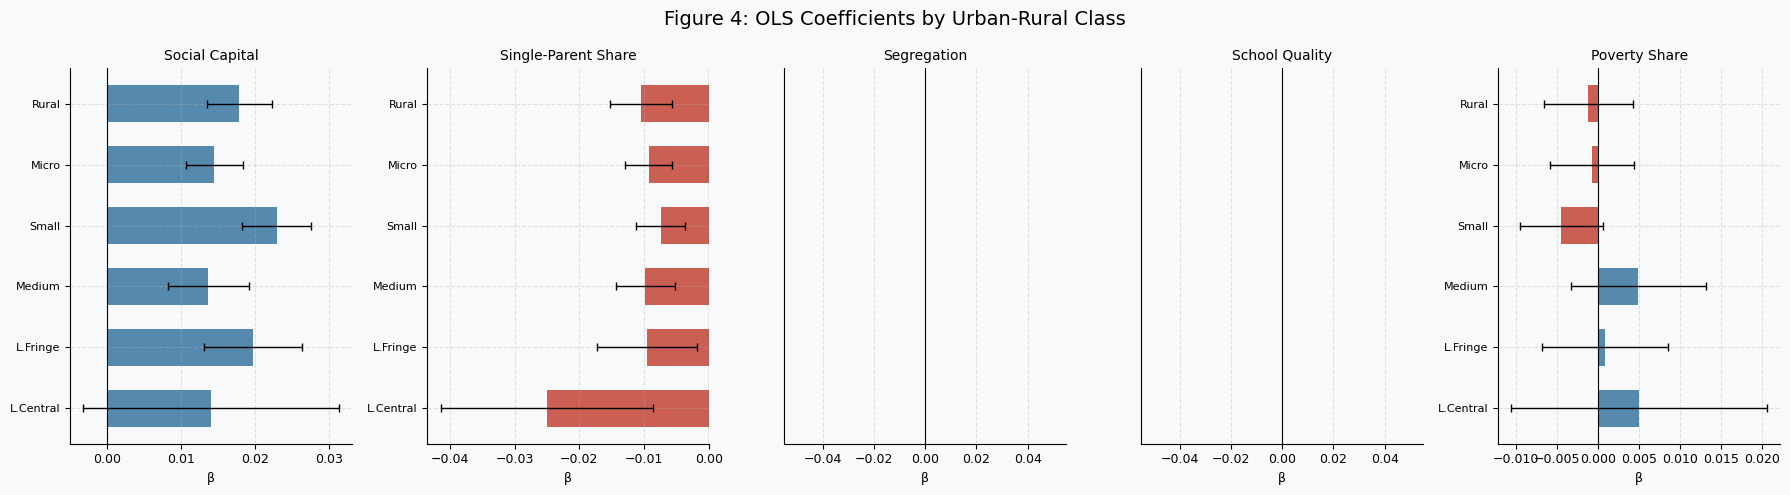

In [13]:
%matplotlib inline

ur_classes = ["Large Central Metro", "Large Fringe Metro", "Medium Metro",
              "Small Metro", "Micropolitan", "Noncore Rural"]
ur_short   = ["L.Central", "L.Fringe", "Medium", "Small", "Micro", "Rural"]

coef_records = []
for ur in ur_classes:
    sub = analytic_std[analytic_std["urban_rural_label"] == ur]
    if len(sub) < 30:
        continue
    X_sub = sm.add_constant(
        StandardScaler().fit_transform(sub[PREDICTORS])
    )
    X_sub = pd.DataFrame(X_sub, columns=["const"] + PREDICTORS)
    res   = sm.OLS(sub["mobility"].values, X_sub).fit(cov_type="HC3")
    for pred in PREDICTORS:
        coef_records.append({
            "ur":   ur,
            "pred": pred_labels.get(pred, pred),
            "coef": res.params[pred],
            "lo":   res.conf_int().loc[pred, 0],
            "hi":   res.conf_int().loc[pred, 1],
        })

coef_df = pd.DataFrame(coef_records)

top_preds = ["Social Capital", "Single-Parent Share", "Segregation",
             "School Quality", "Poverty Share"]
fig, axes = plt.subplots(1, len(top_preds), figsize=(18, 5), sharey=False)
fig.suptitle("Figure 4: OLS Coefficients by Urban-Rural Class", fontsize=14)

for ax, pred in zip(axes, top_preds):
    sub = coef_df[coef_df["pred"] == pred].copy()
    sub = sub[sub["ur"].isin(ur_classes)]
    sub["ur_short"] = sub["ur"].map(dict(zip(ur_classes, ur_short)))
    colors_ = [RED if v < 0 else BLUE for v in sub["coef"]]
    y_pos = np.arange(len(sub))
    ax.barh(y_pos, sub["coef"].values, color=colors_, alpha=0.8, height=0.6)
    ax.errorbar(sub["coef"].values, y_pos,
                xerr=[sub["coef"] - sub["lo"], sub["hi"] - sub["coef"]],
                fmt="none", color="black", lw=1.0, capsize=3)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sub["ur_short"].values, fontsize=8)
    ax.set_title(pred, fontsize=10)
    ax.set_xlabel("β", fontsize=9)

plt.tight_layout()

#### OLS Summary Table

Coefficient table for baseline OLS and interaction OLS side by side, with standard errors and significance stars.

In [14]:
summary_rows = []
for pred in PREDICTORS:
    b0 = ols_base.params[pred]
    se0 = ols_base.bse[pred]
    p0 = ols_base.pvalues[pred]
    b1 = ols_interact.params.get(pred, float("nan"))
    se1 = ols_interact.bse.get(pred, float("nan"))
    p1 = ols_interact.pvalues.get(pred, float("nan"))

    def stars(p):
        if p < 0.01: return "***"
        if p < 0.05: return "**"
        if p < 0.10: return "*"
        return ""

    summary_rows.append({
        "Predictor":          pred_labels.get(pred, pred),
        "β (Baseline)":       f"{b0:.4f}{stars(p0)}",
        "SE (Baseline)":      f"({se0:.4f})",
        "β (Interactions)":   f"{b1:.4f}{stars(p1)}",
        "SE (Interactions)":  f"({se1:.4f})",
    })

results_df = pd.DataFrame(summary_rows)
print(f"Baseline OLS has R²: {ols_base.rsquared:.3f} | Adj R²: {ols_base.rsquared_adj:.3f} | N: {int(ols_base.nobs)}")
print(f"Interaction OLS has R²: {ols_interact.rsquared:.3f} | Adj R²: {ols_interact.rsquared_adj:.3f} | N: {int(ols_interact.nobs)}")
results_df

Baseline OLS has R²: 0.638 | Adj R²: 0.636 | N: 1382
Interaction OLS has R²: 0.641 | Adj R²: 0.637 | N: 1382


,Predictor,β (Baseline),SE (Baseline),β (Interactions),SE (Interactions)
0,Segregation (Racial-Econ),0.0026***,(0.0008),0.0022**,(0.0009)
1,Segregation (Income),-0.0063***,(0.0011),-0.0067***,(0.0011)
2,"School Quality (Score, Adj.)",0.0016*,(0.0009),0.0016*,(0.0009)
3,Student-Teacher Ratio,-0.0000,(0.0007),-0.0001,(0.0007)
4,Single-Parent Share,-0.0125***,(0.0012),-0.0121***,(0.0013)
5,Gini Inequality,0.0017*,(0.0010),0.0017,(0.0010)
6,Mean Commute Time,-0.0052***,(0.0010),-0.0050***,(0.0010)
7,Social Capital,0.0196***,(0.0013),0.0199***,(0.0012)
8,Poverty Share,0.0012,(0.0015),0.0015,(0.0017)
9,Median HH Income,0.0054***,(0.0018),0.0057***,(0.0020)


### Random Forest

Trains a Random Forest regressor on the same 11 standardized predictors and outcome. Hyperparameters tuned via 5-fold cross-validation. Reports OOB R², CV R², and compares to OLS baseline. Feature importance assessed via SHAP values.

OLS R²: 0.638
RF OOB R²: 0.687
RF CV R²: 0.680


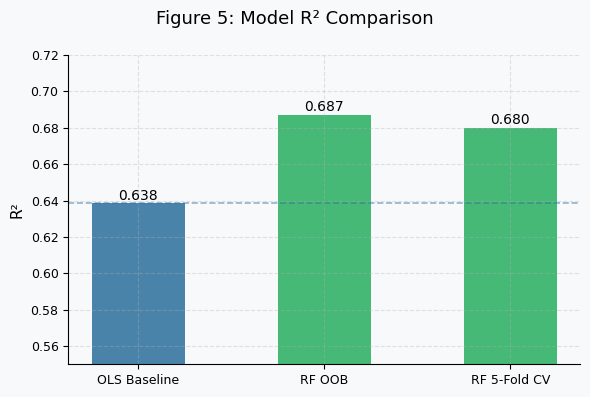

In [15]:
%matplotlib inline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score
import shap

X = X_std.values
y_vals = y.values

rf = RandomForestRegressor(
    n_estimators=500,
    max_features=0.33,
    min_samples_leaf=5,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(X, y_vals)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(rf, X, y_vals, cv=cv, scoring="r2").mean()
oob_r2 = rf.oob_score_
ols_r2 = ols_base.rsquared

print(f"OLS R²: {ols_r2:.3f}")
print(f"RF OOB R²: {oob_r2:.3f}")
print(f"RF CV R²: {cv_r2:.3f}")

# Figure 5: model comparison bar
fig, ax = plt.subplots(figsize=(6, 4))
fig.suptitle("Figure 5: Model R² Comparison", fontsize=13)
labels = ["OLS Baseline", "RF OOB", "RF 5-Fold CV"]
vals = [ols_r2, oob_r2, cv_r2]
colors_ = [BLUE, GREEN, GREEN]
bars = ax.bar(labels, vals, color=colors_, alpha=0.85, width=0.5)
ax.set_ylim(0.55, 0.72)
ax.set_ylabel("R²")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002,
            f"{v:.3f}", ha="center", fontsize=10)
ax.axhline(ols_r2, color=BLUE, lw=1.2, ls="--", alpha=0.5)
plt.tight_layout()

(1) SHAP Values: Feature Importance and Directions

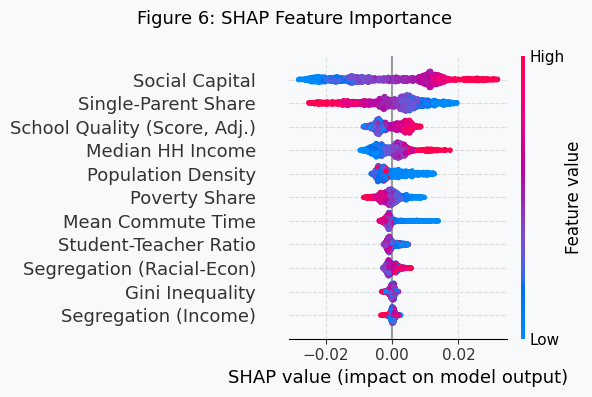

In [16]:
%matplotlib inline

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

shap_df = pd.DataFrame(shap_values, columns=PREDICTORS)

fig, ax = plt.subplots(figsize=(6, 4))
fig.suptitle("Figure 6: SHAP Feature Importance", fontsize=13)
shap.summary_plot(shap_values, X, feature_names=[pred_labels[p] for p in PREDICTORS],
                  show=False, plot_size=None)
plt.tight_layout()

(2) SHAP Interaction Effects: Mean absolute SHAP interaction values between the top feature pairs. Captures how much each pair of features jointly shifts predictions beyond their individual contributions.

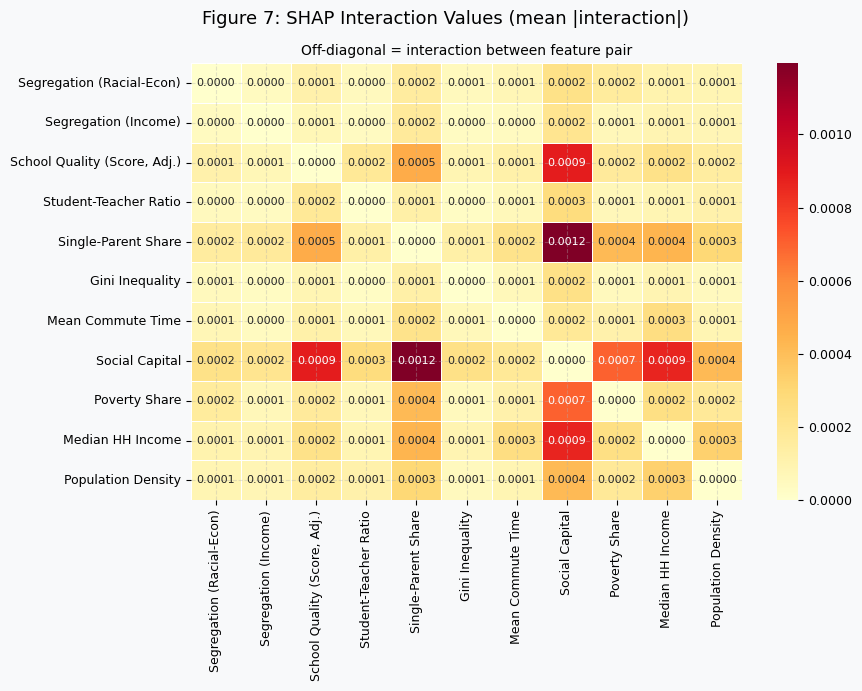

In [17]:
%matplotlib inline

shap_interact = explainer.shap_interaction_values(X)

# Mean absolute interaction matrix (off-diagonal = true interactions)
interact_mat = np.abs(shap_interact).mean(axis=0)
np.fill_diagonal(interact_mat, 0)

labels_short = [pred_labels[p] for p in PREDICTORS]
interact_df  = pd.DataFrame(interact_mat, index=labels_short, columns=labels_short)

fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle("Figure 7: SHAP Interaction Values (mean |interaction|)", fontsize=13)
sns.heatmap(interact_df, ax=ax, cmap="YlOrRd", annot=True, fmt=".4f",
            annot_kws={"size": 8}, linewidths=0.4)
ax.set_title("Off-diagonal = interaction between feature pair", fontsize=10)
plt.tight_layout()

(3) Partial Dependence Plots - Top Features: Shows the marginal effect of each top predictor on mobility, averaging over all other features. Reveals non-linearities the linear model cannot capture.

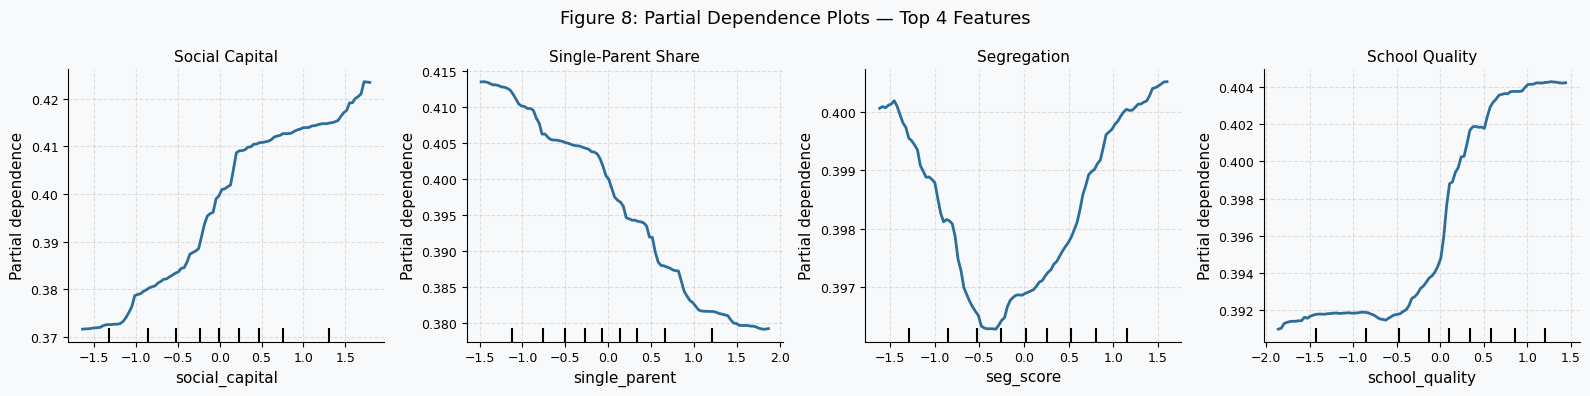

In [18]:
%matplotlib inline
from sklearn.inspection import PartialDependenceDisplay

top4_idx = [PREDICTORS.index(p) for p in
            ["social_capital", "single_parent", "seg_score", "school_quality"]]
top4_labels = ["Social Capital", "Single-Parent Share", "Segregation", "School Quality"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Figure 8: Partial Dependence Plots — Top 4 Features", fontsize=13)

for ax, idx, label in zip(axes, top4_idx, top4_labels):
    PartialDependenceDisplay.from_estimator(
        rf, X, [idx], ax=ax,
        feature_names=PREDICTORS,
        line_kw={"color": BLUE, "lw": 2}
    )
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("")

plt.tight_layout()

### Final Results Table:

In [19]:
import pandas as pd
import numpy as np

# SHAP mean absolute values (overall importance)
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=PREDICTORS
)

# SHAP mean absolute interaction (row sum, excluding diagonal)
interact_importance = pd.Series(
    interact_mat.sum(axis=1),
    index=labels_short
).rename(index={v: k for k, v in pred_labels.items()})

# OLS significance stars
def stars(p):
    if p < 0.01:  return "***"
    if p < 0.05:  return "**"
    if p < 0.10:  return "*"
    return ""

rows = []
for pred in PREDICTORS:
    b   = ols_base.params[pred]
    p   = ols_base.pvalues[pred]
    rows.append({
        "Predictor":            pred_labels[pred],
        "OLS β":                f"{b:.4f}",
        "Sig.":                 stars(p),
        "OLS p-value":          f"{p:.3f}",
        "SHAP Importance":      f"{shap_importance[pred]:.4f}",
        "SHAP Interaction Sum": f"{interact_importance.get(pred, 0):.4f}",
    })

final_df = pd.DataFrame(rows).sort_values(
    "SHAP Importance", ascending=False
).reset_index(drop=True)

print(f"OLS R²: {ols_base.rsquared:.3f} | RF CV R²: {cv_r2:.3f} | "
      f"RF OOB R²: {oob_r2:.3f} | N = {len(analytic)}")
final_df

OLS R²: 0.638 | RF CV R²: 0.680 | RF OOB R²: 0.687 | N = 1382


,Predictor,OLS β,Sig.,OLS p-value,SHAP Importance,SHAP Interaction Sum
0,Social Capital,0.0196,***,0.000,0.0128,0.0052
1,Single-Parent Share,-0.0125,***,0.000,0.0074,0.0036
2,"School Quality (Score, Adj.)",0.0016,*,0.081,0.0038,0.0025
3,Median HH Income,0.0054,***,0.002,0.0038,0.0027
4,Population Density,0.0027,,0.273,0.0035,0.0018
5,Poverty Share,0.0012,,0.424,0.0023,0.0022
6,Mean Commute Time,-0.0052,***,0.000,0.0018,0.0012
7,Student-Teacher Ratio,-0.0000,,0.993,0.0012,0.0010
8,Segregation (Racial-Econ),0.0026,***,0.002,0.0011,0.0011
9,Segregation (Income),-0.0063,***,0.000,0.0005,0.0009
